### Import required libraries.

In [56]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated, Literal
from langchain_cohere import ChatCohere

In [57]:
load_dotenv()

True

In [61]:
# create the schema for Structured output for Sentiment.
class SentimentSchema(BaseModel): 
    sentiment : Literal['positive', 'negative'] = Field(description = 'Sentiment of the review')


# create the schema for structured output for Negative review diagonsis.
class DiagonsisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [62]:
# create the model object. 
model = ChatCohere(
    model="command-a-03-2025",
    temperature=0
)

# Get the structured model.
structured_model = model.with_structured_output(SentimentSchema)

# structured model for diagonsis result.
diagnosis_structured_model = model.with_structured_output(DiagonsisSchema)

In [63]:
prompt = 'Find the sentiment of the given review, the review is The Software is too good'
structured_model.invoke(prompt).sentiment

'positive'

In [64]:
# define the state.
class ReviewState(TypedDict): 
    review : str
    sentiment : Literal["positive", "negative"]
    diagonsis : dict
    response : str 

### Define the nodes in the graph.

In [65]:
# define the find sentiment node.
def find_sentiment(state : ReviewState): 

    review = state['review']

    prompt = f'Find the sentiment of the given review, and the review is {review}'

    sentiment = structured_model.invoke(prompt).sentiment

    return {
        'sentiment' : sentiment
    }

In [75]:
# define the condtion check node.
def check_sentiment(state : ReviewState) -> Literal['positive_response', 'run_diagonsis']:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagonsis'

In [67]:
# difine the positive response node.
def positive_response(state : ReviewState):

    prompt = f"""
            Write a warm thank-you message in response to this review:
            \n\n\"{state['review']}\"\n
            Also, kindly ask the user to leave feedback on our website.
    """

    response = model.invoke(prompt).content

    return {
        'response' : response
    }

In [68]:
# define the run diagonsis node.
def run_diagonsis(state : ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
                "Return issue_type, tone, and urgency.
            """

    response = diagnosis_structured_model.invoke(prompt)

    return {
        'diagonsis' : response.model_dump()
    }

In [69]:
# define the negative response node.
def negative_response(state : ReviewState):

    diagonsis = state['diagonsis']

    prompt = f"""You are a support assistant.
                The user had a '{diagonsis['issue_type']}' issue, sounded '{diagonsis['tone']}', and marked urgency as '{diagonsis['urgency']}'.
                Write an empathetic, helpful resolution message.
            """

    response = model.invoke(prompt).content

    return {
        'response' : response
    }

In [76]:
# build the graph.
graph = StateGraph(ReviewState)

# create the nodes of the graph.
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagonsis', run_diagonsis)
graph.add_node('negative_response', negative_response)

# create the egdes of the graph.
graph.add_edge(START, 'find_sentiment')

# create the conditional edge.
graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)
graph.add_edge('run_diagonsis', 'negative_response')
graph.add_edge('negative_response', END)


# compile the graph.
workflow = graph.compile()

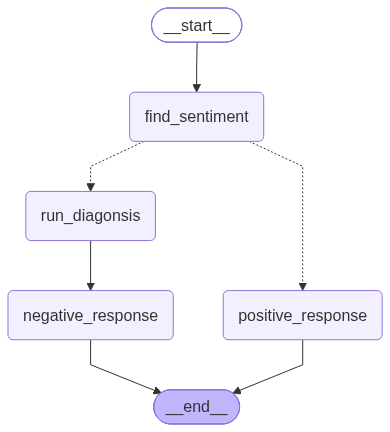

In [77]:
workflow

In [79]:
# define the initial state.
initial_state = {
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.', 'sentiment': 'negative', 'diagonsis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'}, 'response': "**Subject:** We’re Here to Help—Let’s Resolve This Urgently!  \n\nHi [User's Name],  \n\nI’m so sorry to hear you’re experiencing a bug and that it’s causing frustration. I completely understand how important it is to get this resolved quickly, especially when it’s impacting your work or experience. Your urgency is our priority, and we’re committed to helping you as swiftly as possible.  \n\nHere’s what we’re going to do next:  \n1. **Immediate Investigation:** Our technical team is already looking into the issue to identify the root cause.  \n2. **Temporary Workaround:** If available, we’ll provide a temporary solution to help you 